In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import math
from io import BytesIO

# It's recommended to install these libraries first:
# pip install networkx matplotlib


def generate_graph_image(node_counts: list):
    """
    Generates a static graph image with a central root node and nodes
    arranged in concentric circles. The image data is returned as a bytes object.

    The length of the 'node_counts' list determines the number of concentric rings.

    Args:
        node_counts (list): A list of integers defining the graph structure.
                          E.g., [5, 3] creates a central node, 5 primary
                          nodes connected to it in the first ring, and 3
                          secondary nodes connected to each primary node
                          in the second ring.

    Returns:
        bytes: A bytes object containing the PNG image data.
    """
    if not node_counts:
        print("Error: The node_counts list cannot be empty.")
        return

    # Create an empty graph
    G = nx.Graph()

    # Create the central node (level 0)
    central_node = "C0"
    G.add_node(central_node)

    # Store nodes by level to easily calculate positions later
    nodes_by_level = {0: [central_node]}
    parent_nodes = [central_node]

    # Iterate through the node counts to build the graph level by level
    for level, count in enumerate(node_counts):
        current_level_nodes = []
        nodes_by_level[level + 1] = []
        for i, parent_node in enumerate(parent_nodes):
            for j in range(count):
                # Create a unique name for the new node
                new_node_name = f"L{level+1}_P{i}_N{j}"
                G.add_node(new_node_name)
                G.add_edge(parent_node, new_node_name)
                current_level_nodes.append(new_node_name)
                nodes_by_level[level + 1].append(new_node_name)

        # The new nodes become the parent nodes for the next level
        parent_nodes = current_level_nodes

    # --- Graph Visualization ---

    # Set the size of the figure
    plt.figure(figsize=(10, 10))

    # Manually create the position dictionary for concentric circles
    pos = {central_node: (0, 0)}  # Place the central node at the origin

    # Iterate through each level (ring) to position the nodes
    for level, nodes in nodes_by_level.items():
        if level == 0:
            continue  # Skip the central node

        radius = level * 3.0  # Adjust the spacing between rings
        num_nodes_in_level = len(nodes)

        if num_nodes_in_level > 0:
            # Calculate the angular separation for nodes in this ring
            angle_step = 2 * math.pi / num_nodes_in_level

            for i, node in enumerate(nodes):
                angle = i * angle_step
                x = radius * math.cos(angle)
                y = radius * math.sin(angle)
                pos[node] = (x, y)

    # Draw the nodes, coloring them by level for better visual distinction
    node_colors = ["skyblue" for _ in range(len(G.nodes()))]
    color_map = {0: "red", 1: "skyblue", 2: "lightgreen", 3: "yellow"}
    for node, level in nx.shortest_path_length(G, source=central_node).items():
        if level in color_map:
            node_colors[list(G.nodes()).index(node)] = color_map[level]
        else:
            node_colors[list(G.nodes()).index(node)] = "gray"

    nx.draw_networkx_nodes(G, pos, node_size=200, node_color=node_colors)

    # Draw the edges
    nx.draw_networkx_edges(G, pos, width=1.5, alpha=0.7)

    # Draw the labels for the nodes
    labels = {node: node for node in G.nodes() if node != central_node}
    labels[central_node] = "Center"
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=8)

    # Add a title to the graph
    plt.title(f"Generated Graph with {len(node_counts)} Concentric Rings")

    # Use BytesIO to save the plot to a buffer in memory
    buffer = BytesIO()
    plt.savefig(buffer, format="png")

    # Clear the current figure to prepare for the next plot
    plt.clf()

    # Get the value from the buffer and return it
    return buffer.getvalue()

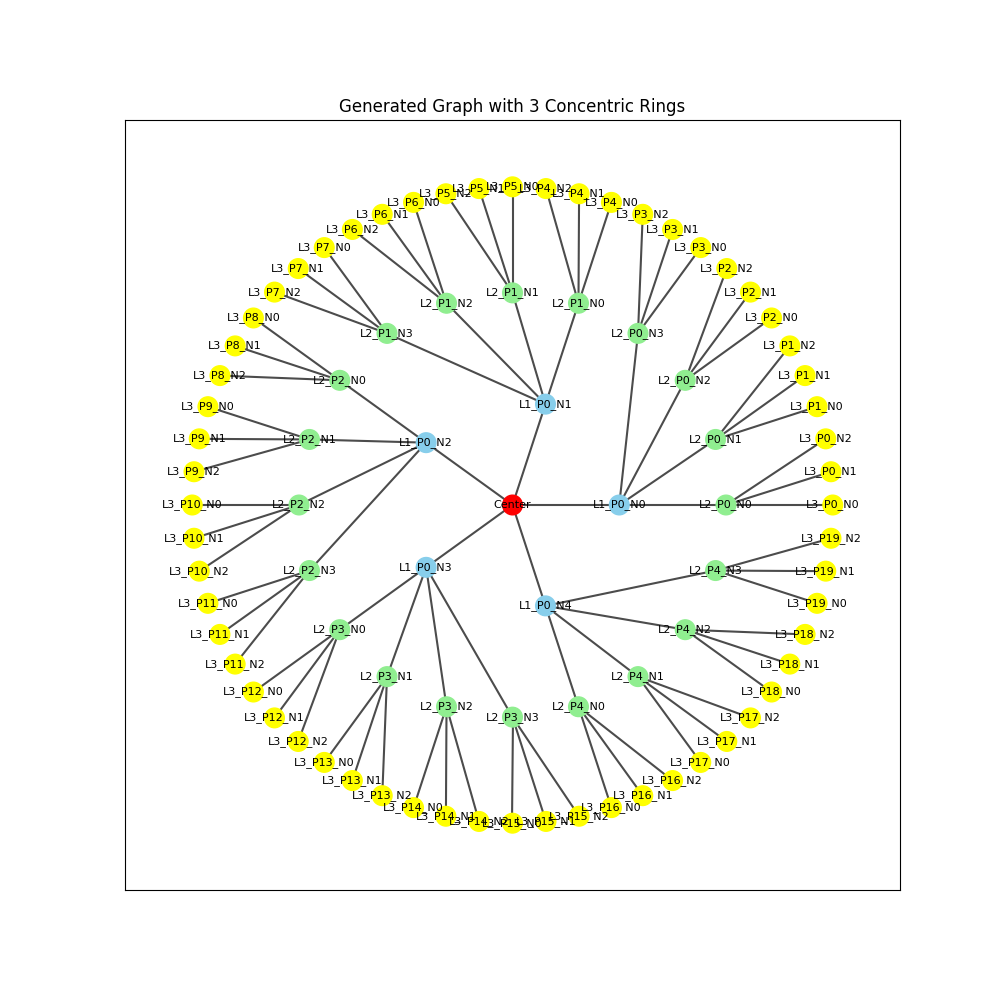

<Figure size 1000x1000 with 0 Axes>

In [ ]:
from IPython.display import Image, display

img_bytes = generate_graph_image(
    [
        5,
        4,
        3,
    ]
)
display(Image(img_bytes))